# Gravitational Lensing: Sersic Source with SIE Lens
## Simulated with JWST NIRCam F200W instrument parameters

This notebook simulates a Sérsic light profile (the source galaxy) being gravitationally lensed by a Singular Isothermal Ellipsoid (SIE) mass model using [lenstronomy](https://github.com/lenstronomy/lenstronomy).

**Instrument: JWST NIRCam, SW channel, Filter F200W (λ = 2.0 μm)**
- Pixel scale: 0.031″/px (native SW channel)
- PSF FWHM ≈ 0.066″ (diffraction-limited Gaussian; λ/D = 2.0 μm / 6.5 m)
- Field of view: ~5″ × 5″ (160 × 160 pixels)

For a fully realistic PSF (including charge diffusion, optical aberrations, etc.) use [WebbPSF](https://webbpsf.readthedocs.io/) to generate a pixel-sampled PSF kernel and pass it via `psf_type='PIXEL'`.

**Physics background:**
- **SIE lens**: A mass distribution with an isothermal density profile (ρ ∝ 1/r²) and elliptical symmetry. Characterized by an Einstein radius θ_E and axis ratio.
- **Sérsic profile**: A parametric light profile with intensity I(r) ∝ exp(−b_n [(r/r_eff)^(1/n) − 1]). The index n controls the shape (n=1 → exponential disk, n=4 → de Vaucouleurs).
- **Lensing**: The SIE deflects light from the background Sérsic source, creating distorted arcs or Einstein rings.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.ImSim.Numerics.numerics_subframe import NumericsSubFrame
from lenstronomy.Util import util
from lenstronomy.Util import image_util
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF

print('lenstronomy imported successfully')

lenstronomy imported successfully


## 1. Set up the imaging grid

In [73]:
# Image grid parameters — JWST NIRCam SW channel, F200W
num_pixels = 160          # pixels per side
pixel_scale = 0.031       # arcsec/pixel (NIRCam SW native plate scale)

# Build coordinate grid
ra_at_xy_0, dec_at_xy_0 = -(num_pixels / 2) * pixel_scale, -(num_pixels / 2) * pixel_scale
transform_pix2angle = np.array([[pixel_scale, 0], [0, pixel_scale]])

kwargs_data = {
    'image_data': np.zeros((num_pixels, num_pixels)),
    'ra_at_xy_0': ra_at_xy_0,
    'dec_at_xy_0': dec_at_xy_0,
    'transform_pix2angle': transform_pix2angle,
}

data = ImageData(**kwargs_data)
print(f'Image: {num_pixels}×{num_pixels} pixels, {pixel_scale}\'\'/px  →  {num_pixels*pixel_scale:.2f}\'\'×{num_pixels*pixel_scale:.2f}\'\' FoV')

Image: 160×160 pixels, 0.031''/px  →  4.96''×4.96'' FoV


## 2. Define the PSF

In [74]:
# JWST NIRCam F200W PSF — Gaussian approximation
# FWHM ≈ 0.066" at 2.0 μm  (diffraction limit: λ/D = 2.0e-6 / 6.5 * 206265 ≈ 0.063")
# The true PSF has weak diffraction spikes and broader wings; use WebbPSF for pixel-level fidelity.
kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': 0.066, 'pixel_size': pixel_scale}
psf = PSF(**kwargs_psf)
print(f'PSF: Gaussian, FWHM = {kwargs_psf["fwhm"]}" '
      f'({kwargs_psf["fwhm"] / pixel_scale:.1f} px)  —  NIRCam F200W approximation')

PSF: Gaussian, FWHM = 0.066" (2.1 px)  —  NIRCam F200W approximation


## 3. Define the SIE lens model

In [75]:
# SIE: Singular Isothermal Ellipsoid
lens_model_list = ['SIE']
lens_model = LensModel(lens_model_list=lens_model_list)

kwargs_sie = {
    'theta_E': 1.0,     # Einstein radius [arcsec] — sets the lensing strength
    'e1': 0.1,          # ellipticity component 1 (aligned with x-axis)
    'e2': 0.0,         # ellipticity component 2 (45° rotated)
    'center_x': 0.0,    # lens centre x [arcsec]
    'center_y': 0.0,    # lens centre y [arcsec]
}
kwargs_lens = [kwargs_sie]
print('SIE lens: θ_E =', kwargs_sie['theta_E'], '"\'  e1 =', kwargs_sie['e1'], ' e2 =', kwargs_sie['e2'])

SIE lens: θ_E = 1.0 "'  e1 = 0.1  e2 = 0.0


## 4. Define the Sérsic source light profile

In [76]:
# Sérsic profile for the background source galaxy
source_model_list = ['SERSIC_ELLIPSE']
source_model = LightModel(light_model_list=source_model_list)

kwargs_sersic_source = {
    'amp': 100.0,          # amplitude (surface brightness at r_eff)
    'R_sersic': 0.3,       # effective (half-light) radius [arcsec]
    'n_sersic': 2.0,       # Sérsic index  (1=disk-like, 4=de Vaucouleurs)
    'e1': 0.0,             # source ellipticity component 1
    'e2': -0.0,            # source ellipticity component 2
    'center_x': 0.05,      # source centre x (small offset from lens centre)
    'center_y': 0.1,       # source centre y
}
kwargs_source = [kwargs_sersic_source]
print('Sérsic source:  R_eff =', kwargs_sersic_source['R_sersic'],
      '"  n =', kwargs_sersic_source['n_sersic'],
      '  position = ({}, {}) "'.format(kwargs_sersic_source['center_x'], kwargs_sersic_source['center_y']))

Sérsic source:  R_eff = 0.3 "  n = 2.0   position = (0.05, 0.1) "


## 5. (Optional) Add a lens light profile

In [77]:
# de Vaucouleurs (Sérsic n=4) profile for the foreground lens galaxy
lens_light_model_list = ['SERSIC_ELLIPSE']
lens_light_model = LightModel(light_model_list=lens_light_model_list)

kwargs_lens_light = [{
    'amp': 200.0,
    'R_sersic': 0.5,
    'n_sersic': 4.0,   # de Vaucouleurs
    'e1': 0.05,
    'e2': 0.02,
    'center_x': 0.0,
    'center_y': 0.0,
}]
print('Lens light: de Vaucouleurs (n=4), R_eff =', kwargs_lens_light[0]['R_sersic'], '"')

Lens light: de Vaucouleurs (n=4), R_eff = 0.5 "


## 6. Build the image model and render images

In [78]:
# Numerics: sub-pixel sampling for accurate rendering
kwargs_numerics = {'supersampling_factor': 3, 'supersampling_convolution': False}

# Full model: lens mass + lens light + lensed source
image_model_full = ImageModel(
    data_class=data,
    psf_class=psf,
    lens_model_class=lens_model,
    source_model_class=source_model,
    lens_light_model_class=lens_light_model,
    kwargs_numerics=kwargs_numerics,
)

# Lensed source only (no lens light) — to see the arcs clearly
image_model_arcs = ImageModel(
    data_class=data,
    psf_class=psf,
    lens_model_class=lens_model,
    source_model_class=source_model,
    kwargs_numerics=kwargs_numerics,
)

# Unlensed source (no lens, same position) — for comparison
image_model_unlensed = ImageModel(
    data_class=data,
    psf_class=psf,
    lens_model_class=LensModel(lens_model_list=[]),  # empty lens
    source_model_class=source_model,
    kwargs_numerics=kwargs_numerics,
)

# Render
img_full      = image_model_full.image(kwargs_lens, kwargs_source, kwargs_lens_light, kwargs_ps=None)
img_arcs      = image_model_arcs.image(kwargs_lens, kwargs_source, kwargs_lens_light=None, kwargs_ps=None)
img_unlensed  = image_model_unlensed.image(kwargs_lens=[], kwargs_source=kwargs_source, kwargs_lens_light=None, kwargs_ps=None)

print('Images rendered  — max values:',
      f'full={img_full.max():.1f}  arcs={img_arcs.max():.1f}  unlensed={img_unlensed.max():.1f}')

Images rendered  — max values: full=13.0  arcs=1.5  unlensed=1.1


## 7. Compute deflection angles and critical curves

In [79]:
# Build a coordinate grid for plotting deflections
x_grid, y_grid = util.make_grid(numPix=num_pixels, deltapix=pixel_scale)

# Deflection angles
alpha_x, alpha_y = lens_model.alpha(x_grid, y_grid, kwargs_lens)
alpha_x_2d = util.array2image(alpha_x)
alpha_y_2d = util.array2image(alpha_y)

# Convergence κ (dimensionless surface mass density)
kappa = lens_model.kappa(x_grid, y_grid, kwargs_lens)
kappa_2d = util.array2image(kappa)

# Magnification μ
magnification = lens_model.magnification(x_grid, y_grid, kwargs_lens)
magnification_2d = util.array2image(magnification)

print('Deflection field computed')

Deflection field computed


## 8. Visualise

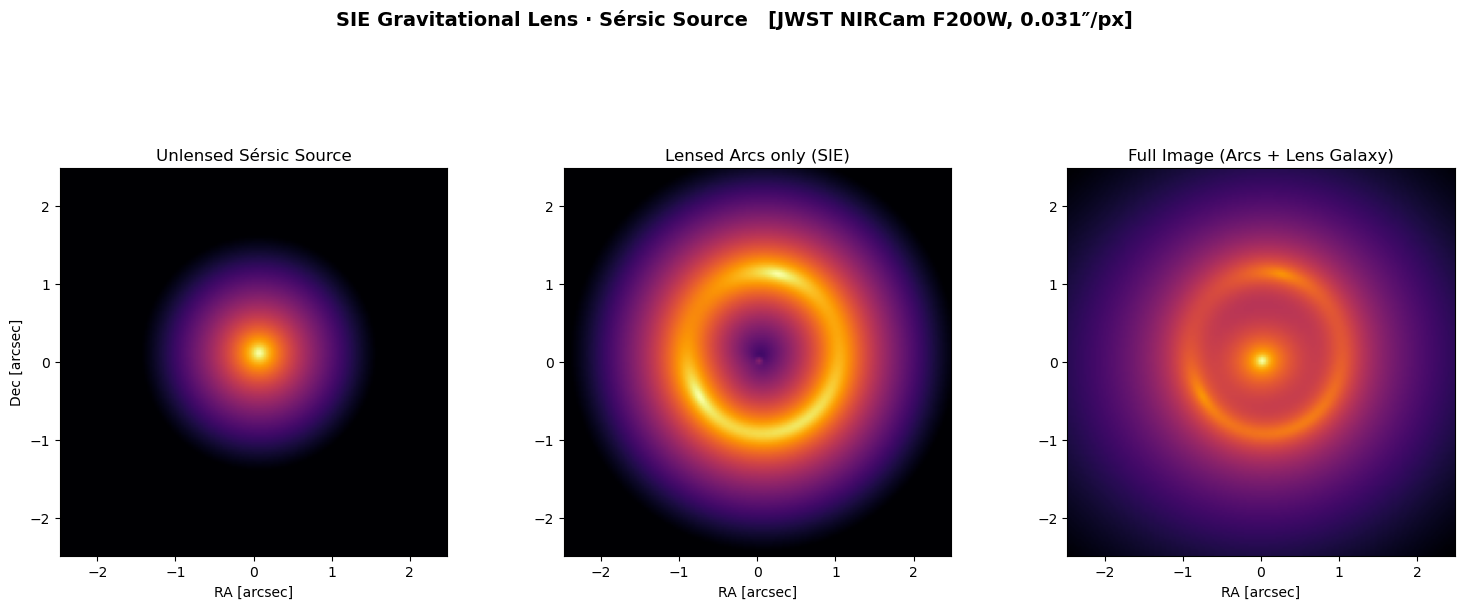

Figure saved to sersic_sie_lensing.png


In [80]:
extent = [-num_pixels * pixel_scale / 2, num_pixels * pixel_scale / 2,
          -num_pixels * pixel_scale / 2, num_pixels * pixel_scale / 2]

def log_stretch(img, floor=1e-3):
    """Logarithmic stretch for display."""
    img = np.clip(img, floor, None)
    return np.log10(img)

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# --- Row 1: light images ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(log_stretch(img_unlensed), origin='lower', extent=extent, cmap='inferno')
ax1.set_title('Unlensed Sérsic Source', fontsize=12)
ax1.set_xlabel('RA [arcsec]'); ax1.set_ylabel('Dec [arcsec]')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(log_stretch(img_arcs), origin='lower', extent=extent, cmap='inferno')
ax2.set_title('Lensed Arcs only (SIE)', fontsize=12)
ax2.set_xlabel('RA [arcsec]')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(log_stretch(img_full), origin='lower', extent=extent, cmap='inferno')
ax3.set_title('Full Image (Arcs + Lens Galaxy)', fontsize=12)
ax3.set_xlabel('RA [arcsec]')

    # # --- Row 2: lens plane quantities ---
    # ax4 = fig.add_subplot(gs[1, 0])
    # im4 = ax4.imshow(np.log10(np.clip(kappa_2d, 1e-4, None)),
    #                 origin='lower', extent=extent, cmap='viridis')
    # ax4.set_title('Convergence κ (log scale)', fontsize=12)
    # ax4.set_xlabel('RA [arcsec]'); ax4.set_ylabel('Dec [arcsec]')
    # plt.colorbar(im4, ax=ax4, label='log₁₀ κ')

    # ax5 = fig.add_subplot(gs[1, 1])
    # mu_display = np.clip(np.abs(magnification_2d), 0, 50)
    # im5 = ax5.imshow(mu_display, origin='lower', extent=extent, cmap='plasma')
    # ax5.set_title('Magnification |μ| (clipped at 50)', fontsize=12)
    # ax5.set_xlabel('RA [arcsec]')
    # plt.colorbar(im5, ax=ax5, label='|μ|')

    # ax6 = fig.add_subplot(gs[1, 2])
    # alpha_mag = np.sqrt(alpha_x_2d**2 + alpha_y_2d**2)
    # step = 10
    # xx = np.linspace(extent[0], extent[1], num_pixels)[::step]
    # yy = np.linspace(extent[2], extent[3], num_pixels)[::step]
    # XX, YY = np.meshgrid(xx, yy)
    # ax6.imshow(alpha_mag, origin='lower', extent=extent, cmap='cividis', alpha=0.6)
    # ax6.quiver(XX, YY,
    #         alpha_x_2d[::step, ::step],
    #         alpha_y_2d[::step, ::step],
    #         color='white', alpha=0.8, scale=15)
    # ax6.set_title('Deflection Angles α', fontsize=12)
    # ax6.set_xlabel('RA [arcsec]')

fig.suptitle('SIE Gravitational Lens · Sérsic Source   [JWST NIRCam F200W, 0.031″/px]',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('sersic_sie_lensing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to sersic_sie_lensing.png')

## 9. Critical curves and caustics

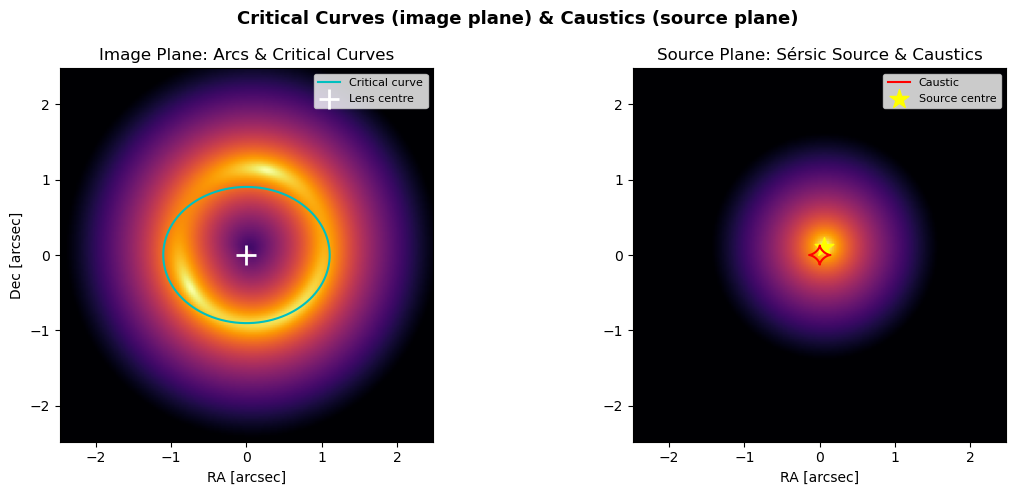

Figure saved to critical_caustic.png


In [81]:
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions

lens_ext = LensModelExtensions(lensModel=lens_model)
ra_crit_list, dec_crit_list, ra_caustic_list, dec_caustic_list = lens_ext.critical_curve_caustics(
    kwargs_lens, compute_window=num_pixels * pixel_scale, grid_scale=pixel_scale / 2
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Image plane: lensed arcs + critical curves
axes[0].imshow(log_stretch(img_arcs), origin='lower', extent=extent, cmap='inferno')
for ra_c, dec_c in zip(ra_crit_list, dec_crit_list):
    axes[0].plot(ra_c, dec_c, 'c-', lw=1.5, label='Critical curve')
axes[0].scatter(kwargs_sie['center_x'], kwargs_sie['center_y'],
                marker='+', s=200, c='white', lw=2, label='Lens centre')
axes[0].set_title('Image Plane: Arcs & Critical Curves', fontsize=12)
axes[0].set_xlabel('RA [arcsec]'); axes[0].set_ylabel('Dec [arcsec]')
axes[0].legend(fontsize=8)

# Source plane: unlensed source + caustics
axes[1].imshow(log_stretch(img_unlensed), origin='lower', extent=extent, cmap='inferno')
for ra_ca, dec_ca in zip(ra_caustic_list, dec_caustic_list):
    axes[1].plot(ra_ca, dec_ca, 'r-', lw=1.5, label='Caustic')
axes[1].scatter(kwargs_sersic_source['center_x'], kwargs_sersic_source['center_y'],
                marker='*', s=200, c='yellow', lw=1, label='Source centre')
axes[1].set_title('Source Plane: Sérsic Source & Caustics', fontsize=12)
axes[1].set_xlabel('RA [arcsec]')
axes[1].legend(fontsize=8)

fig.suptitle('Critical Curves (image plane) & Caustics (source plane)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('critical_caustic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to critical_caustic.png')

## 10. Parameter exploration — vary the Sérsic index

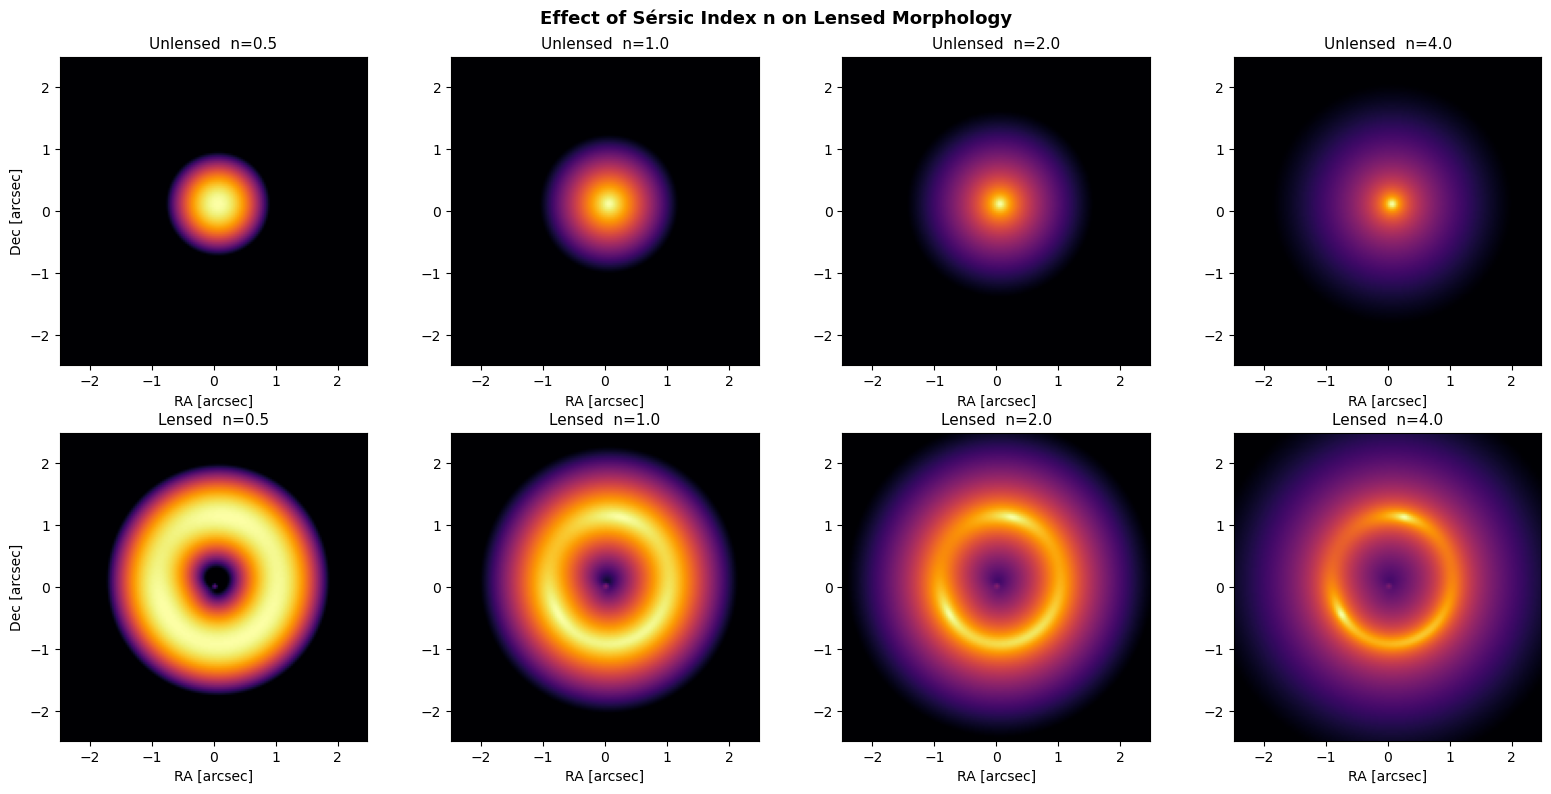

Figure saved to sersic_index_comparison.png


In [82]:
n_values = [0.5, 1.0, 2.0, 4.0]   # Sérsic indices to compare

fig, axes = plt.subplots(2, len(n_values), figsize=(16, 8))

for i, n in enumerate(n_values):
    kw_src = [{**kwargs_sersic_source, 'n_sersic': n}]

    # Unlensed
    img_ul = image_model_unlensed.image([], kw_src, None, None)
    # Lensed
    img_l  = image_model_arcs.image(kwargs_lens, kw_src, None, None)

    axes[0, i].imshow(log_stretch(img_ul), origin='lower', extent=extent, cmap='inferno')
    axes[0, i].set_title(f'Unlensed  n={n}', fontsize=11)
    axes[0, i].set_xlabel('RA [arcsec]')
    if i == 0:
        axes[0, i].set_ylabel('Dec [arcsec]')

    axes[1, i].imshow(log_stretch(img_l), origin='lower', extent=extent, cmap='inferno')
    axes[1, i].set_title(f'Lensed  n={n}', fontsize=11)
    axes[1, i].set_xlabel('RA [arcsec]')
    if i == 0:
        axes[1, i].set_ylabel('Dec [arcsec]')

fig.suptitle('Effect of Sérsic Index n on Lensed Morphology', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sersic_index_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to sersic_index_comparison.png')

## 11. Magnification & flux statistics

In [83]:
total_flux_unlensed = np.sum(img_unlensed)
total_flux_lensed   = np.sum(img_arcs)
flux_magnification  = total_flux_lensed / total_flux_unlensed

print('=== Lensing Statistics ===')
print(f'Total flux (unlensed) : {total_flux_unlensed:.2f}')
print(f'Total flux (lensed)   : {total_flux_lensed:.2f}')
print(f'Flux magnification    : {flux_magnification:.3f}×')
print()

# Einstein radius check
theta_E = kwargs_sie['theta_E']
print(f'SIE Einstein radius   : {theta_E:.2f} "')
print(f'Source offset from OA : ({kwargs_sersic_source["center_x"]:.2f}, {kwargs_sersic_source["center_y"]:.2f}) "')
src_r = np.sqrt(kwargs_sersic_source['center_x']**2 + kwargs_sersic_source['center_y']**2)
print(f'Source radial offset  : {src_r:.3f} "  (θ_E = {theta_E:.2f} ")')
print(f'Source inside caustic : {src_r < theta_E}')

=== Lensing Statistics ===
Total flux (unlensed) : 146.10
Total flux (lensed)   : 1414.04
Flux magnification    : 9.678×

SIE Einstein radius   : 1.00 "
Source offset from OA : (0.05, 0.10) "
Source radial offset  : 0.112 "  (θ_E = 1.00 ")
Source inside caustic : True
